In [1]:
import astropy
from astropy.table import Table
import astropy.units as u
import numpy as np
import os, sys

In [2]:
def between(lo, x, hi):
    return (lo < x) * (x < hi)

In [3]:
# not detected: mag =  99; magerr = 1-sigma upper limit assuming zero flux
# not observed: mag = -99; magerr = 0
def fluxes2mags(flux, fluxerr):
    nondet = flux < 0  # Non-detection if flux is negative
    unobs = (fluxerr <= 0) + (fluxerr == np.inf)  # Unobserved if flux uncertainty is negative or infinity

    mag = flux.to(u.ABmag)
    magupperlimit = fluxerr.to(u.ABmag) # 1-sigma upper limit if flux=0

    mag = np.where(nondet, 99 * u.ABmag, mag)
    mag = np.where(unobs, -99 * u.ABmag, mag)

    magerr = 2.5 * np.log10(1 + fluxerr/flux) 
    magerr = magerr.value * u.ABmag

    magerr = np.where(nondet, magupperlimit, magerr)
    magerr = np.where(unobs, 0 * u.ABmag, magerr)
    
    return mag, magerr

In [4]:
def extract_id(cat, id, idlabel='id'):
    # Note input id must be same format as cat[idlabel] (int or string)
    # to create an array with mostly False entries and True for id
    # cat['id'] dtype='int64'
    # cat['id'] == 3: [False, False, True, False...]
    # cat['id'] == '3': False
    #
    # obj:          astropy.table.table.Table
    # obj[0]:       astropy.table.row.Row
    # obj['id']:    astropy.table.column.Column
    # obj[0]['id']: numpy.int64
    duck_duck_goose = cat[idlabel] == int(id)
    if len(duck_duck_goose):
        obj = cat[duck_duck_goose]
    return obj[0]

In [5]:
field = 'whl0137'
indir = '../eazy_v4'
infile = field + '_phot-eazy.ecsv'
infile = os.path.join(indir, infile)

catalog = astropy.io.ascii.read(infile)

In [6]:
catalog[:2]

id,ra,dec,f090w_flux,f090w_fluxerr,f105w_flux,f105w_fluxerr,f110w_flux,f110w_fluxerr,f115w_flux,f115w_fluxerr,f125w_flux,f125w_fluxerr,f140w_flux,f140w_fluxerr,f150w_flux,f150w_fluxerr,f160w_flux,f160w_fluxerr,f200w_flux,f200w_fluxerr,f277w_flux,f277w_fluxerr,f356w_flux,f356w_fluxerr,f410m_flux,f410m_fluxerr,f435w_flux,f435w_fluxerr,f444w_flux,f444w_fluxerr,f475w_flux,f475w_fluxerr,f606w_flux,f606w_fluxerr,f814w_flux,f814w_fluxerr,z_spec,nusefilt,z_ml,z_ml_chi2,z_ml_risk,lc_min,lc_max,z_phot,z_phot_chi2,z_phot_risk,z_min_risk,min_risk,z_raw_chi2,raw_chi2,z025,z160,z500,z840,z975,restU,restU_err,restB,restB_err,restV,restV_err,restJ,restJ_err,dL,mass,sfr,Lv,LIR,energy_abs,Lu,Lj,L1400,L2800,LHa,LOIII,LHb,LOII,MLv,Av,lwAgeV,mass_p,sfr_p,Lv_p,LIR_p,energy_abs_p,Lu_p,Lj_p,L1400_p,L2800_p,LHa_p,LOIII_p,LHb_p,LOII_p,Av_p,ssfr_p,rest120,rest120_err,rest121,rest121_err,rest414,rest414_err,rest415,rest415_err,rest416,rest416_err,flux,peak,flux_radius
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,Mpc,solMass,solMass / yr,solLum,solLum,solLum,solLum,solLum,solLum,solLum,solLum,solLum,solLum,solLum,solMass / solLum,,Gyr,,,,,,,,,,,,,,,,,,,,,,,,,,uJy,uJy,
int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,int64,float32,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64
1,24.390374,-8.500793,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-1.0,0,-1.0,-1.0,-1.0,43188281021088.9,0.0,-1.0,-1.0,-1.0,0.01,0.0,0.01,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-99.000,0.000,-99.000,0.000,-99.000,0.000,-99.000,0.000,0.0e+00,-9.00e+29,-900000000000000046043660025856.000,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-900000000000000046043660025856.00,-900000000000000046043660025856.00,-900000000000000046043660025856.00,-9.00e+29 .. -9.00e+29,-900000000000000046043660025856.000 .. -900000000000000046043660025856.000,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-9.00e+29 .. -9.00e+29,-900000000000000046043660025856.00 .. -900000000000000046043660025856.00,-9.00e+29 .. -9.00e+29,-99.000,0.000,-99.000,0.000,-99.000,0.000,-99.000,0.000,-99.000,0.000,0.02426156584177849,1.3804176471542673e-05,0.0
2,24.379928,-8.500794,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000,-1.0,0,-1.0,-1.0,-1.0,43188281021088.9,0.0,-1.0,-1.0,-1.0,0.01,0.0,0.01,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-99.000,0.000,-99.000,0.000,-99.000,0.000,-99.000,0.000,0.0e+00,-9.00e+29,-900000000000000046043660025856.000,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00e+29,-9.00

In [7]:
# Reconstitute filters
filters = []
for label in catalog.columns:
    if label.endswith('_flux'):
        filters.append(label[:-5])
        
#filters

In [8]:
#filters = 'f090w f115w f150w f200w f277w f356w f410m f444w'.split()

In [9]:
# flux -> mag

flux_units = u.uJy

for filt in filters:
    label = filt + '_flux'
    flux = catalog[filt+'_flux']
    fluxerr = catalog[filt+'_fluxerr']
    #flux = flux.to(u.uJy).value
    #fluxerr = fluxerr.to(u.uJy).value
    nan_flux = np.isnan(flux)
    flux = np.where(nan_flux, 0, flux)
    fluxerr = np.where(nan_flux, 1e30, fluxerr)
    mag, magerr = fluxes2mags(flux * flux_units, fluxerr * flux_units)
    #mag, magerr = fluxes2mags(flux, fluxerr)
    #cat[filt+'_flux'] = flux
    #cat[filt+'_fluxerr'] = fluxerr
    catalog[filt+'_mag'] = mag.value
    catalog[filt+'_magerr'] = magerr.value

/Users/dcoe/miniconda3/envs/erophot/lib/python3.10/site-packages/astropy/units/function/logarithmic.py:47: RuntimeWarning: invalid value encountered in log10
  return dex.to(self._function_unit, np.log10(x))
/Users/dcoe/miniconda3/envs/erophot/lib/python3.10/site-packages/astropy/units/quantity.py:611: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [10]:
mag1 = catalog['f200w_mag']
mag2 = catalog['f444w_mag']
mag = np.where(between(0, mag2, 90), mag2, mag1)
bright = (30 - mag) * between(0, mag, 90)
bright = np.clip(bright, -99, 10)
np.min(bright), np.max(bright)

(-4.109787, 10.0)

In [11]:
z = catalog['z_phot']
z025 = catalog['z025']
highz = (z + z025) * (z < 17)
dust = catalog['Av']
dust = dust * (dust > 0)
weight = highz + dust + bright
weight = weight * (z > 0)
weight = weight * between(0, catalog['z_phot_chi2'], 100)
weight /= 4
np.min(weight), np.max(weight)

(-0.413887915056627, 8.869158519719406)

In [12]:
len(catalog), catalog['id'][-1]

(5750, 5750)

In [13]:
catalog['fwhm'] = 2 * catalog['flux_radius'] * 0.02

In [14]:
catalog['size'] = catalog['fwhm']

In [15]:
catalog['magnitude'] = mag

mag_err = catalog['f200w_magerr']
catalog['magnitude_error'] = magerr

In [16]:
catalog['weight'] = weight

In [17]:
catalog['reference'] = 0  # reference object? 0 or 1
# WHL0137 MSATA reference objects.ipynb
#reference_object_ids = 4613, 1745, 816, 170, 3632, 3885, 1649, 2056, 1195, 2170, 1442, 3078, 1251, 1569, 2498, 2776, 144, 693, 733, 1673, 5697, 631, 111, 1961, 4699, 2174, 3359, 238, 2575, 5704, 1981, 2755, 3599, 3687
reference_object_ids = 4613, 1745, 816, 170, 3710, 1901, 1621, 3632, 1026, 1084, 2341, 5606, 3885, 1649, 1740, 1045, 760, 4258, 2056, 1195, 4426, 2170, 1442, 3078, 1251, 1569, 2498, 2776, 144, 693, 3153, 433, 376, 3036, 733, 1673, 1648, 5463, 2745, 2252, 5697, 631, 5590, 4776, 111, 4908, 1961, 4699, 2174, 1540, 3359, 238, 2073, 2575, 1856, 5704, 2581, 1981, 4136, 2755, 1593, 2464, 3599, 985, 802, 3687
ii = np.array(reference_object_ids) - 1
catalog['reference'][ii] = 1

In [18]:
catalog['redshift'] = catalog['z_phot']

In [19]:
catalog['NRS_F110W'] = catalog['f115w_mag']
catalog['NRS_F140X'] = catalog['f150w_mag']
catalog['NRS_CLEAR'] = catalog['f200w_mag']

# piXedfit catalog

some object weights may get overridden below by science catalog

In [20]:
piXedfit_catalog = astropy.io.ascii.read('catalog_pixedfit_WHL0137.cat', format='commented_header', header_start=-1)
catalog['weight'][piXedfit_catalog['id']-1] = 150  # if multiplying science by 10

In [21]:
piXedfit_catalog = astropy.io.ascii.read('catalog_pixedfit_WHL0137_blank_field.cat', format='commented_header', header_start=-1)
catalog['weight'][piXedfit_catalog['id']-1] = 150  # if multiplying science by 10

In [22]:
piXedfit_catalog[:2]

id1,id,z_phot,log_mass,log_sfr,log_ssfr
int64,int64,float64,float64,float64,float64
1,2727,1.34126,10.388062,1.766954,-8.621108
2,2736,1.696043,11.600893,2.230498,-9.370395


# Adam massive logM > 10, z > 2

In [23]:
catalog['weight'][1062-1] = 60 * 10
catalog['weight'][3359-1] = 90 * 10
catalog['weight'][3972-1] = 70 * 10
catalog['weight'][4783-1] =120 * 10
catalog['weight'][5113-1] = 20 * 10

# Guillaume's lensed galaxies

In [24]:
catalog['weight'][ 899-1] = 60 * 10
catalog['weight'][ 952-1] = 80 * 10
catalog['weight'][1534-1] = 90 * 10
catalog['weight'][1663-1] =100 * 10
catalog['weight'][ 836-1] =100 * 10

# Rosa's galaxies

In [25]:
catalog['weight'][179-1] = 70 * 10
catalog['weight'][180-1] = 70 * 10
catalog['weight'][ 98-1] = 70 * 10
catalog['weight'][122-1] = 90 * 10
catalog['weight'][187-1] = 40 * 10
catalog['weight'][ 38-1] = 30 * 10
catalog['weight'][ 39-1] = 20 * 10
catalog['weight'][ 40-1] = 25 * 10

# highest weights

In [26]:
#catalog.sort('weight')
#catalog = catalog[::-1]
#catalog[:10]
# maybe high-z: 2318 1558 4646 4629 3301 1400 3768 5300

In [27]:
#catalog['stellarity'] = 

In [28]:
# no stellarity in the grizli catalogs...
inroot = 'sunrise-grizli-v4.0'
infile = inroot + '-fix_phot_apcorr.fits'
infile = inroot + '-fix_phot.fits'
#infile = inroot + '-ir.cat.fits'
infile = os.path.join(indir, infile)
eazy_phot = Table.read(infile)
#eazy_phot[:2]

# Highest Priority Science Targets

In [29]:
MSA_infile = 'WHL0137_MSA2.cat'
science_catalog = astropy.io.ascii.read(MSA_infile, format='commented_header', header_start=-1)

In [30]:
i = list(science_catalog['id']).index(18888)  # interloper
science_catalog['weight'][i] = 200  # higher than it was: 50

In [31]:
science_catalog['weight'] *= 10  # keep lower than 1e6
science_catalog

id,RA,Dec,fwhm,magnitude,magnitude_error,weight
int64,float64,float64,float64,float64,float64,int64
10000,24.346859,-8.464519,0.2,27.0,0.1,100000
10001,24.346627,-8.464261,0.2,27.0,0.1,30000
10002,24.34713,-8.464757,0.2,27.0,0.1,30000
10003,24.3497,-8.466426,0.2,27.0,0.1,3000
10020,24.347544,-8.465079,0.2,27.0,0.1,20000
10200,24.348603,-8.465836,0.2,27.0,0.1,5000
11000,24.346388,-8.464001,0.2,27.0,0.1,10000
11001,24.346427,-8.464052,0.2,27.0,0.1,8000
12001,24.34793,-8.465371,0.2,27.0,0.1,15000


In [32]:
science_catalog['reference'] = 0  # reference object? 0 or 1
science_catalog['NRS_F110W'] = science_catalog['magnitude']
science_catalog['NRS_F140X'] = science_catalog['magnitude']
science_catalog['NRS_CLEAR'] = science_catalog['magnitude']

In [33]:
existing_objects = science_catalog[science_catalog['id'] < 10000]
existing_objects[:3]

id,RA,Dec,fwhm,magnitude,magnitude_error,weight,reference,NRS_F110W,NRS_F140X,NRS_CLEAR
int64,float64,float64,float64,float64,float64,int64,int64,float64,float64,float64
1392,24.346034,-8.456814,0.4,22.03,0.0,3000,0,22.03,22.03,22.03
1391,24.345969,-8.457053,0.32,22.45,0.0,900,0,22.45,22.45,22.45
1395,24.3464,-8.458581,0.67,22.06,0.01,700,0,22.06,22.06,22.06


In [34]:
ii = existing_objects['id'] - 1
catalog['weight'][ii] = existing_objects['weight']

In [35]:
new_science_catalog = science_catalog[science_catalog['id'] >= 10000]
new_science_catalog['redshift'] = 6.2
new_science_catalog

id,RA,Dec,fwhm,magnitude,magnitude_error,weight,reference,NRS_F110W,NRS_F140X,NRS_CLEAR,redshift
int64,float64,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64
10000,24.346859,-8.464519,0.2,27.0,0.1,100000,0,27.0,27.0,27.0,6.2
10001,24.346627,-8.464261,0.2,27.0,0.1,30000,0,27.0,27.0,27.0,6.2
10002,24.34713,-8.464757,0.2,27.0,0.1,30000,0,27.0,27.0,27.0,6.2
10003,24.3497,-8.466426,0.2,27.0,0.1,3000,0,27.0,27.0,27.0,6.2
10020,24.347544,-8.465079,0.2,27.0,0.1,20000,0,27.0,27.0,27.0,6.2
10200,24.348603,-8.465836,0.2,27.0,0.1,5000,0,27.0,27.0,27.0,6.2
11000,24.346388,-8.464001,0.2,27.0,0.1,10000,0,27.0,27.0,27.0,6.2
11001,24.346427,-8.464052,0.2,27.0,0.1,8000,0,27.0,27.0,27.0,6.2
12001,24.34793,-8.465371,0.2,27.0,0.1,15000,0,27.0,27.0,27.0,6.2


In [36]:
catalog.rename_column('ra', 'RA')
catalog.rename_column('dec', 'Dec')

In [37]:
columns = 'id RA Dec redshift fwhm magnitude magnitude_error weight reference NRS_F110W NRS_F140X NRS_CLEAR'.split() # stellarity

In [38]:
output_catalog = catalog[columns]
output_catalog = output_catalog[output_catalog['redshift'] > 0]
output_catalog[:2]

id,RA,Dec,redshift,fwhm,magnitude,magnitude_error,weight,reference,NRS_F110W,NRS_F140X,NRS_CLEAR
,,,,,,mag(AB),,,,,
int32,float64,float64,float32,float64,float32,float32,float64,int64,float32,float32,float32
5,24.341293,-8.480021,0.56193113,0.27384608792150866,25.99387,0.066072166,1.2324901256393035,0,25.468018,25.34945,25.073502
6,24.342626,-8.479826,4.9465284,0.02326030643875761,26.771696,0.83266544,3.6457114772225894,0,99.0,99.0,30.208889


In [39]:
output_catalog = astropy.table.vstack([new_science_catalog, output_catalog])

In [40]:
output_catalog = output_catalog[columns]
output_catalog

id,RA,Dec,redshift,fwhm,magnitude,magnitude_error,weight,reference,NRS_F110W,NRS_F140X,NRS_CLEAR
,,,,,,mag(AB),,,,,
int64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64
10000,24.346859,-8.464519,6.2,0.2,27.0,0.1,100000.0,0,27.0,27.0,27.0
10001,24.346627,-8.464261,6.2,0.2,27.0,0.1,30000.0,0,27.0,27.0,27.0
10002,24.347130,-8.464757,6.2,0.2,27.0,0.1,30000.0,0,27.0,27.0,27.0
10003,24.349700,-8.466426,6.2,0.2,27.0,0.1,3000.0,0,27.0,27.0,27.0
10020,24.347544,-8.465079,6.2,0.2,27.0,0.1,20000.0,0,27.0,27.0,27.0
10200,24.348603,-8.465836,6.2,0.2,27.0,0.1,5000.0,0,27.0,27.0,27.0
11000,24.346388,-8.464001,6.2,0.2,27.0,0.1,10000.0,0,27.0,27.0,27.0
11001,24.346427,-8.464052,6.2,0.2,27.0,0.1,8000.0,0,27.0,27.0,27.0


In [41]:
output_catalog['fwhm'].info.format = '%.3f'
for label in 'magnitude magnitude_error NRS_F110W NRS_F140X NRS_CLEAR'.split():
    output_catalog[label].info.format = '%6.3f'

In [42]:
#output_catalog.write('WHL0137_full_MSA8.cat', format='ascii.commented_header', delimiter=' ', overwrite=True)
len(output_catalog)

5627

In [43]:
HSTinfile = '/Users/dcoe/RELICS/data/whl0137-08/JWST/catalogs/HST/whl0137_f814w_detections.ecsv'
HST_catalog = astropy.io.ascii.read(HSTinfile)
HST_catalog[:2]

id,x,y,ra,dec,area,a,b,fwhm,ellipticity,orientation,gini,kron_radius,local_background,segment_flux,segment_fluxerr,kron_flux,kron_fluxerr,segment_mag,segment_magerr,kron_mag,kron_magerr
,,,deg,deg,pix2,pix,pix,pix,,deg,,pix,,nJy,nJy,nJy,nJy,mag(AB),mag(AB),mag(AB),mag(AB)
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float64,float64,float64,float64,float64
1,nan,nan,nan,nan,262275.0,nan,nan,nan,nan,nan,0.9855737121070509,nan,3.479845218736924e-13,0.0007942034490130466,inf,nan,nan,-99.0,0.0,nan,nan
2,nan,nan,nan,nan,1300.0,nan,nan,nan,nan,nan,0.5162607857431682,nan,-2.728077031649994e-39,5.673791807272399e-34,inf,nan,nan,-99.0,0.0,nan,nan


In [44]:
HST_catalog.rename_column('kron_mag', 'magnitude')
HST_catalog.rename_column('kron_magerr', 'magnitude_error')

In [45]:
HST_catalog['redshift'] = 0.111
HST_catalog['weight'] = 0.1  # will multiply by 10 below...
HST_catalog['reference'] = 0
HST_catalog['NRS_F110W'] = HST_catalog['magnitude']
HST_catalog['NRS_F140X'] = HST_catalog['magnitude']
HST_catalog['NRS_CLEAR'] = HST_catalog['magnitude']

In [46]:
# WHL0137 MSATA HST reference objects.ipynb
#reference_object_ids = 4227, 5490, 904, 5967, 3217, 5487, 3288, 3485, 4680, 4750, 3879, 2530, 3408, 3486
reference_object_ids = 4654, 3043, 5011, 4227, 3026, 5490, 904, 5967, 4412, 3201, 3217, 5487, 4267, 6055, 3288, 4254, 4167, 3457, 4104, 3485, 4680, 4750, 3879, 2530, 5631, 3207, 3408, 5132, 4134, 3486, 3431, 2871
ii = np.array(reference_object_ids) - 1
HST_catalog['reference'][ii] = 1

In [47]:
# Q3
HST_catalog['weight'][10297-1] = 30
HST_catalog['weight'][10295-1] = 25
HST_catalog['weight'][10303-1] = 20
HST_catalog['weight'][10305-1] = 20
HST_catalog['weight'][10108-1] = 20
HST_catalog['weight'][10440-1] = 15
HST_catalog['weight'][10119-1] = 15
HST_catalog['weight'][4007-1]  = 15
HST_catalog['weight'][10055-1] = 15
HST_catalog['weight'][9957-1]  = 12
HST_catalog['weight'][10421-1] = 12
HST_catalog['weight'][10392-1] = 12

In [48]:
# Q2
HST_catalog['weight'][10647-1] = 20
HST_catalog['weight'][10646-1] = 15
HST_catalog['weight'][10651-1] = 12
HST_catalog['weight'][10653-1] = 10
HST_catalog['weight'][10643-1] = 10
HST_catalog['weight'][5559-1] = 10
HST_catalog['weight'][10635-1] = 10
HST_catalog['weight'][10670-1] = 10
HST_catalog['weight'][10604-1] = 10
HST_catalog['weight'][10598-1] = 12
HST_catalog['weight'][10607-1] = 12
HST_catalog['weight'][10620-1] = 12
HST_catalog['weight'][10697-1] = 12

In [49]:
HST_catalog['weight'] *= 10

In [50]:
nothing = np.isnan(HST_catalog['x'])
HST_catalog = HST_catalog[np.logical_not(nothing)]

In [51]:
HST_catalog.rename_column('ra', 'RA')
HST_catalog.rename_column('dec', 'Dec')

In [52]:
HST_catalog['id'] = 80000 + np.arange(len(HST_catalog))

In [53]:
HST_catalog[:2]

id,x,y,RA,Dec,area,a,b,fwhm,ellipticity,orientation,gini,kron_radius,local_background,segment_flux,segment_fluxerr,kron_flux,kron_fluxerr,segment_mag,segment_magerr,magnitude,magnitude_error,redshift,weight,reference,NRS_F110W,NRS_F140X,NRS_CLEAR
,,,deg,deg,pix2,pix,pix,pix,,deg,,pix,,nJy,nJy,nJy,nJy,mag(AB),mag(AB),mag(AB),mag(AB),,,,mag(AB),mag(AB),mag(AB)
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64
80000,3999.487873403575,172.73635174029855,24.35018054565958,-8.498886225669185,8.0,0.8598072910429992,0.5943190503486934,1.7404045556383156,0.3087764473039677,-68.28400254183977,0.6495543658617534,1.4,0.0019167234416265643,15.542422418485225,inf,12.687718073185552,inf,-99.0,0.0,-99.0,0.0,0.111,1.0,0,-99.0,-99.0,-99.0
80001,4008.4622283268177,172.89480991273098,24.350079723499764,-8.498884463771196,8.0,0.8148596214291963,0.5613038412486918,1.6475817846605876,0.31116498291544825,-24.540752545012804,0.7086602472429038,1.4,0.0007477722002279836,15.01603365888896,inf,12.714294136998992,inf,-99.0,0.0,-99.0,0.0,0.111,1.0,0,-99.0,-99.0,-99.0


In [54]:
from astropy.coordinates import SkyCoord

In [55]:
#%matplotlib inline
%matplotlib notebook
import matplotlib.pyplot as plt

In [56]:
output_catalog_coordinates = SkyCoord(ra=output_catalog['RA']*u.deg, dec=output_catalog['Dec']*u.deg)

In [57]:

HST_distances = []
for i in range(len(HST_catalog)):
    obj_coordinates = SkyCoord(ra=HST_catalog['RA'][i], dec=HST_catalog['Dec'][i])
    distances = obj_coordinates.separation(output_catalog_coordinates)
    dist = np.min(distances).to(u.arcsec).value
    HST_distances.append(dist)

In [58]:
#HST_distances

<IPython.core.display.Javascript object>


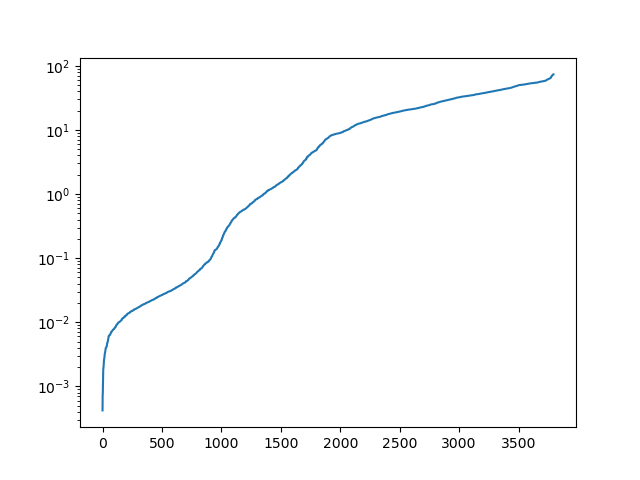

[]

In [59]:
plt.plot(np.sort(HST_distances))
plt.semilogy()

In [60]:
HST_only = np.array(HST_distances) > 10  # " away
add_HST_catalog = HST_catalog[HST_only]
len(add_HST_catalog), len(HST_catalog)

(1735, 3794)

In [61]:
add_HST_catalog = add_HST_catalog[columns]

In [62]:
add_HST_catalog['fwhm'] *= 0.04

In [63]:
add_HST_catalog

id,RA,Dec,redshift,fwhm,magnitude,magnitude_error,weight,reference,NRS_F110W,NRS_F140X,NRS_CLEAR
,deg,deg,,pix,mag(AB),mag(AB),,,mag(AB),mag(AB),mag(AB)
int64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64
80000,24.35018054565958,-8.498886225669185,0.111,0.06961618222553263,-99.0,0.0,1.0,0,-99.0,-99.0,-99.0
80001,24.350079723499764,-8.498884463771196,0.111,0.0659032713864235,-99.0,0.0,1.0,0,-99.0,-99.0,-99.0
80002,24.350225191400177,-8.498804438144852,0.111,0.13752261280783454,99.0,17.27820610112999,1.0,0,99.0,99.0,99.0
80003,24.3503227390976,-8.498798447349008,0.111,0.10311980439379388,-99.0,0.0,1.0,0,-99.0,-99.0,-99.0
80004,24.35000846134759,-8.498766726324124,0.111,0.07111429001625813,-99.0,0.0,1.0,0,-99.0,-99.0,-99.0
80005,24.350510354714476,-8.498620724454598,0.111,0.11490246429650981,-99.0,0.0,1.0,0,-99.0,-99.0,-99.0
80006,24.350650566248326,-8.49851510578967,0.111,0.060655788519835135,-99.0,0.0,1.0,0,-99.0,-99.0,-99.0
80007,24.35084437282259,-8.49834285665614,0.111,0.1032192329039349,-99.0,0.0,1.0,0,-99.0,-99.0,-99.0


In [64]:
for column in columns:
    output_catalog[column] = output_catalog[column].value
    add_HST_catalog[column] = add_HST_catalog[column].value

In [65]:
JWST_HST_output_catalog = astropy.table.vstack([output_catalog, add_HST_catalog])

In [66]:
JWST_HST_output_catalog

id,RA,Dec,redshift,fwhm,magnitude,magnitude_error,weight,reference,NRS_F110W,NRS_F140X,NRS_CLEAR
int64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64
10000,24.346859,-8.464519,6.2,0.2,27.0,0.1,100000.0,0,27.0,27.0,27.0
10001,24.346627,-8.464261,6.2,0.2,27.0,0.1,30000.0,0,27.0,27.0,27.0
10002,24.34713,-8.464757,6.2,0.2,27.0,0.1,30000.0,0,27.0,27.0,27.0
10003,24.3497,-8.466426,6.2,0.2,27.0,0.1,3000.0,0,27.0,27.0,27.0
10020,24.347544,-8.465079,6.2,0.2,27.0,0.1,20000.0,0,27.0,27.0,27.0
10200,24.348603,-8.465836,6.2,0.2,27.0,0.1,5000.0,0,27.0,27.0,27.0
11000,24.346388,-8.464001,6.2,0.2,27.0,0.1,10000.0,0,27.0,27.0,27.0
11001,24.346427,-8.464052,6.2,0.2,27.0,0.1,8000.0,0,27.0,27.0,27.0
12001,24.34793,-8.465371,6.2,0.2,27.0,0.1,15000.0,0,27.0,27.0,27.0


In [67]:
#JWST_HST_output_catalog.write('WHL0137_full_MSA8.cat', format='ascii.commented_header', delimiter=' ', overwrite=True)
len(JWST_HST_output_catalog)

7362

<IPython.core.display.Javascript object>


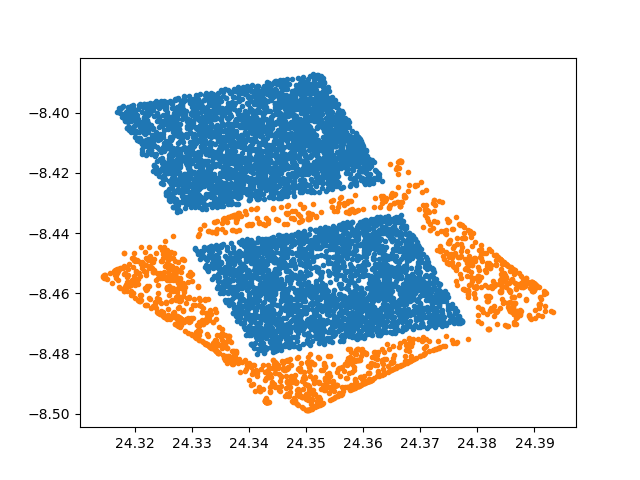

In [68]:
fig = plt.figure()
plt.plot(output_catalog['RA'], output_catalog['Dec'], '.')
plt.plot(add_HST_catalog['RA'], add_HST_catalog['Dec'], '.')
#plt.semilogy()

In [69]:
output_catalog

id,RA,Dec,redshift,fwhm,magnitude,magnitude_error,weight,reference,NRS_F110W,NRS_F140X,NRS_CLEAR
int64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64
10000,24.346859,-8.464519,6.2,0.2,27.0,0.1,100000.0,0,27.0,27.0,27.0
10001,24.346627,-8.464261,6.2,0.2,27.0,0.1,30000.0,0,27.0,27.0,27.0
10002,24.34713,-8.464757,6.2,0.2,27.0,0.1,30000.0,0,27.0,27.0,27.0
10003,24.3497,-8.466426,6.2,0.2,27.0,0.1,3000.0,0,27.0,27.0,27.0
10020,24.347544,-8.465079,6.2,0.2,27.0,0.1,20000.0,0,27.0,27.0,27.0
10200,24.348603,-8.465836,6.2,0.2,27.0,0.1,5000.0,0,27.0,27.0,27.0
11000,24.346388,-8.464001,6.2,0.2,27.0,0.1,10000.0,0,27.0,27.0,27.0
11001,24.346427,-8.464052,6.2,0.2,27.0,0.1,8000.0,0,27.0,27.0,27.0
12001,24.34793,-8.465371,6.2,0.2,27.0,0.1,15000.0,0,27.0,27.0,27.0


# Background slits near Sunrise Arc

In [70]:
#dgrid = 0.00002

In [71]:
# small space between arc and other galaxy
RA1, Dec1 = 24.34631, -8.46374  # bottom right
RA2, Dec2 = 24.34652, -8.46360  # top left
#RAgridNW, DecgridNW = np.meshgrid(np.arange(RA1,RA2,dgrid), np.arange(Dec1,Dec2,dgrid))
DecgridNW, RAgridNW = np.mgrid[Dec1:Dec2:10j, RA1:RA2:10j]

In [72]:
# larger space to the north
RA1, Dec1 = 24.34600, -8.46327  # bottom right
RA2, Dec2 = 24.34672, -8.46229  # top left
DecgridNW2, RAgridNW2 = np.mgrid[Dec1:Dec2:10j, RA1:RA2:10j]
#RAgridNW2, DecgridNW2 = np.meshgrid(np.arange(RA1,RA2,dgrid), np.arange(Dec1,Dec2,dgrid))

In [73]:
# large space to the south
RA1, Dec1 = 24.34867, -8.46777  # bottom right
RA2, Dec2 = 24.35050, -8.46681  # top left
DecgridSE, RAgridSE = np.mgrid[Dec1:Dec2:10j, RA1:RA2:10j]
#RAgridSE, DecgridSE = np.meshgrid(np.arange(RA1,RA2,dgrid), np.arange(Dec1,Dec2,dgrid))

In [74]:
background_catalog = Table()

In [75]:
background_catalog['RA']  = np.concatenate([RAgridNW.flat,  RAgridNW2.flat,  RAgridSE.flat])
background_catalog['Dec'] = np.concatenate([DecgridNW.flat, DecgridNW2.flat, DecgridSE.flat])

In [76]:
background_catalog['id'] = 20000 + np.arange(len(background_catalog))

In [77]:
background_catalog['redshift'] = 66
background_catalog['fwhm'] = -1
background_catalog['magnitude'] = -99
background_catalog['magnitude_error'] = -99
background_catalog['weight'] = 1000
background_catalog['reference'] = 0
background_catalog['NRS_F110W'] = -99
background_catalog['NRS_F140X'] = -99
background_catalog['NRS_CLEAR'] = -99

In [78]:
background_catalog['weight'][:100]    = 222
background_catalog['weight'][100:200] = 222
background_catalog['weight'][200:300] = 222

# Maybe it needs better numbers to work properly
background_catalog['redshift'] = 66
background_catalog['fwhm'] = 1
background_catalog['magnitude'] = 28
background_catalog['magnitude_error'] = 0.3
background_catalog['reference'] = 0
background_catalog['NRS_F110W'] = 28
background_catalog['NRS_F140X'] = 28
background_catalog['NRS_CLEAR'] = 28

In [79]:
background_catalog[:2]

RA,Dec,id,redshift,fwhm,magnitude,magnitude_error,weight,reference,NRS_F110W,NRS_F140X,NRS_CLEAR
float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64
24.34631,-8.46374,20000,66,1,28,0,222,0,28,28,28
24.346333333333334,-8.46374,20001,66,1,28,0,222,0,28,28,28


In [80]:
len(background_catalog)

300

In [81]:
JWST_HST_background_output_catalog = astropy.table.vstack([JWST_HST_output_catalog, background_catalog])

In [82]:
#JWST_HST_background_output_catalog.write('WHL0137_full_MSA9c.cat', format='ascii.commented_header', delimiter=' ', overwrite=True)
len(JWST_HST_background_output_catalog)

7662

<IPython.core.display.Javascript object>


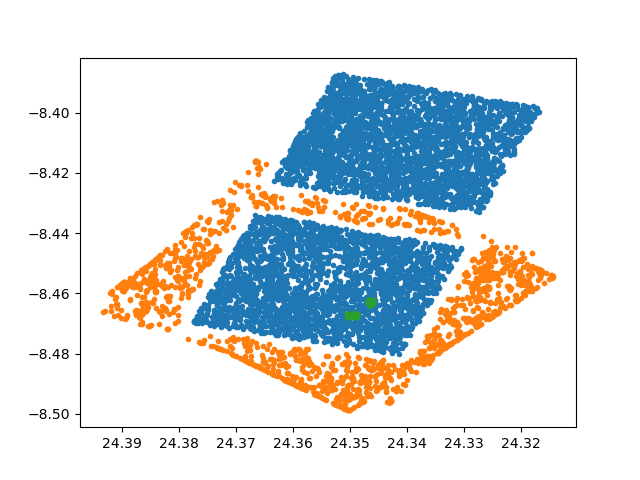

(24.39727245127405, 24.310354723317165)

In [83]:
fig = plt.figure()
plt.plot(output_catalog['RA'],  output_catalog['Dec'],  '.')
plt.plot(add_HST_catalog['RA'], add_HST_catalog['Dec'], '.')

plt.plot(background_catalog['RA'], background_catalog['Dec'], '.')
plt.xlim(plt.xlim()[::-1])

#plt.semilogy()

# Background Grid across the FOV

In [84]:
#RA1 = np.min(science_catalog['RA'])
#RA2 = np.max(science_catalog['RA'])
RA1, RA2 = 24.3, 24.385  # right left

Dec1 = np.min(science_catalog['Dec'])
Dec2 = np.max(science_catalog['Dec'])

Decgridfull, RAgridfull = np.mgrid[Dec1:Dec2:40j, RA1:RA2:30j]

<IPython.core.display.Javascript object>


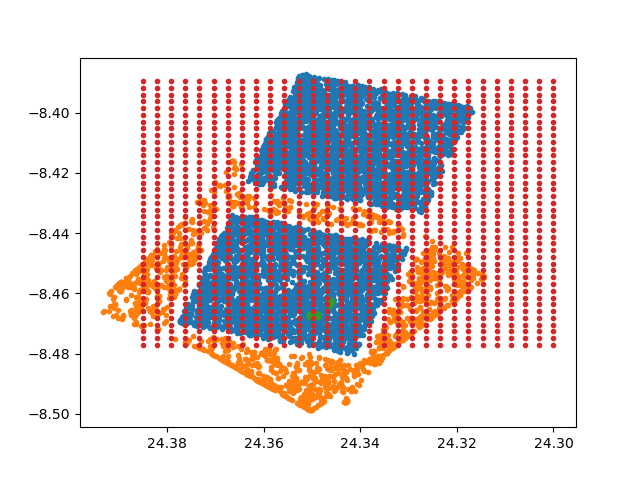

(24.39798772773072, 24.29533391772711)

In [85]:
fig = plt.figure()
plt.plot(output_catalog['RA'],  output_catalog['Dec'],  '.')
plt.plot(add_HST_catalog['RA'], add_HST_catalog['Dec'], '.')

plt.plot(background_catalog['RA'], background_catalog['Dec'], '.')
plt.plot(RAgridfull.flat, Decgridfull.flat, '.')

plt.xlim(plt.xlim()[::-1])

#plt.semilogy()

In [86]:
segm_dir = '../eazy_v4'
segm_file = 'sunrise-grizli-v4.0-ir_20mas_seg.fits.gz'
segm_file = os.path.join(segm_dir, segm_file)
segm_hdu = astropy.io.fits.open(segm_file)[0]
segm_data = segm_hdu.data

In [87]:
import photutils

In [88]:
segm = photutils.segmentation.SegmentationImage(segm_data)

In [89]:
segm_wcs = astropy.wcs.WCS(segm_hdu.header)
segm_wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 24.355  -8.457  
CRPIX : 7142.5  7886.5  
CD1_1 CD1_2  : -5.5555555555555e-06  0.0  
CD2_1 CD2_2  : 0.0  5.5555555555555e-06  
NAXIS : 17600  24000

In [90]:
catalog_coordinates = SkyCoord(ra=science_catalog['RA']*u.deg, dec=science_catalog['Dec']*u.deg)  # *u.deg
science_catalog['x'], science_catalog['y'] = segm_wcs.world_to_pixel(catalog_coordinates)

In [91]:
def add_xy_to_catalog(catalog):
    catalog_coordinates = SkyCoord(ra=catalog['RA']*u.deg, dec=catalog['Dec']*u.deg)  # *u.deg
    catalog['x'], catalog['y'] = segm_wcs.world_to_pixel(catalog_coordinates)

In [92]:
#add_xy_to_catalog(background_catalog)

In [93]:
catalog_coordinates = SkyCoord(ra=RAgridfull.flat*u.deg, dec=Decgridfull.flat*u.deg)  # *u.deg
x, y = segm_wcs.world_to_pixel(catalog_coordinates)

In [94]:
def roundint(x):
    return int(np.round(x))

In [95]:
n = len(y)
background_segms = []
for i in range(n):
    background_segms.append(segm_data[roundint(y[i]), roundint(x[i])])

In [96]:
segm_data.shape

(24000, 17600)

In [97]:
background_segm_free = np.logical_not(background_segms)

In [98]:
xback = x[background_segm_free]
yback = y[background_segm_free]

In [99]:
background_grid = Table()
background_grid['RA']  = RAgridfull.flat
background_grid['Dec'] = Decgridfull.flat
background_grid['id'] = 30000 + np.arange(n)

In [100]:
background_grid['weight'] = 5

# Maybe it needs better numbers to work properly
background_grid['redshift'] = 67
background_grid['fwhm'] = 1
background_grid['magnitude'] = 28
background_grid['magnitude_error'] = 0.3
background_grid['reference'] = 0
background_grid['NRS_F110W'] = 28
background_grid['NRS_F140X'] = 28
background_grid['NRS_CLEAR'] = 28

In [101]:
JWST_HST_background2_output_catalog = astropy.table.vstack([JWST_HST_background_output_catalog, background_grid])

In [102]:
JWST_HST_background2_output_catalog.write('WHL0137_full_MSA18.cat', format='ascii.commented_header', delimiter=' ') #, overwrite=True)
len(JWST_HST_background2_output_catalog)

8862

In [103]:
weight5 = JWST_HST_background2_output_catalog['weight'] > 4.99
weight5_catalog = JWST_HST_background2_output_catalog[weight5]
weight5_catalog.write('WHL0137_weight5_MSA18.cat', format='ascii.commented_header', delimiter=' ') #, overwrite=True
len(weight5_catalog)

2079

<IPython.core.display.Javascript object>


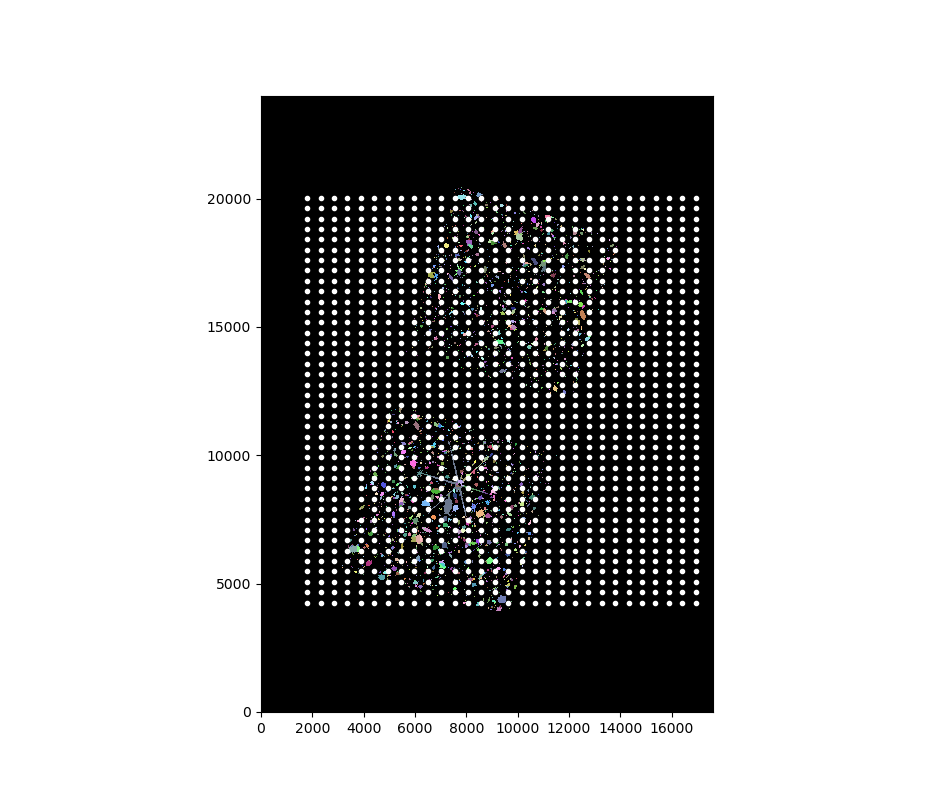

In [104]:
fig = plt.figure(figsize=(9.5,8))
cmap = segm.make_cmap(seed=12345)
plt.imshow(segm_data, cmap=cmap, interpolation='None', origin='lower')
plt.plot(xback, yback, 'w.')